# Melbourne House Prices: EDA and Data Preparation

## Objective
This notebook performs exploratory data analysis on the Melbourne house prices dataset, identifies data quality issues, develops business insights, and prepares a modelling-ready dataset for predictive modelling.



## Dataset Description

The dataset contains these variables:

- `Rooms`: Number of rooms
- `Type`: Property type (`h`, `u`, `t`)
- `Price`: Sale price in dollars
- `Method`: Selling method
- `Regionname`: Broad Melbourne region
- `Bathroom`: Number of bathrooms
- `Car`: Number of car spots
- `Landsize`: Land size of the property
- `Distance`: Distance from Melbourne CBD
- `Bedroom`: Number of bedrooms



In [28]:
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 40)

DATA_PATH = Path("house.csv")
PREPARED_PATH = Path("melbourne_prepared_for_modeling.csv")

int_cols = ["Rooms", "Price", "Bathroom", "Car", "Bedroom"]
float_cols = ["Landsize", "Distance"]
numeric_cols = ["Rooms", "Price", "Bathroom", "Car", "Landsize", "Distance", "Bedroom"]
categorical_cols = ["Type", "Method", "Regionname"]



In [17]:
df = pd.read_csv(DATA_PATH)
for column in int_cols:
    df[column] = df[column].astype(int)
for column in float_cols:
    df[column] = df[column].astype(float)

records = df.to_dict(orient="records")

print(f"Rows: {len(df)}")
print(f"Columns: {', '.join(df.columns)}")
print()
print("Preview of first 5 rows")
print(df.head().to_string(index=False))



Rows: 4766
Columns: Rooms, Type, Price, Method, Regionname, Bathroom, Car, Landsize, Distance, Bedroom

Preview of first 5 rows
 Rooms Type   Price Method            Regionname  Bathroom  Car  Landsize  Distance  Bedroom
     3    h 1490000      S Northern Metropolitan         1    1     126.0      25.2        2
     3    h 1220000      S Northern Metropolitan         1    1     202.0      21.8        2
     3    h 1420000      S Northern Metropolitan         1    0     156.0      21.7        2
     3    h 1515000      S  Western Metropolitan         2    1       0.0      18.8        3
     2    h  670000      S  Western Metropolitan         2    0     134.0      20.6        3


## Initial Read Insight

The dataset contains **4,766 rows** and **10 columns**, which is large enough for useful predictive modelling but still small enough for full-record inspection. The structure is clean and compact, with a mix of numeric and categorical variables that are directly relevant to house pricing.



In [18]:
def format_value(value):
    if pd.isna(value):
        return ""
    if isinstance(value, float):
        if value.is_integer():
            return f"{int(value):,}"
        return f"{value:,.3f}"
    if isinstance(value, int):
        return f"{value:,}"
    if value is None:
        return ""
    return str(value)


def print_df(title, rows, columns=None, max_rows=None):
    if title:
        print(title)
    if max_rows is not None:
        if isinstance(rows, pd.DataFrame):
            rows = rows.head(max_rows)
        else:
            rows = rows[:max_rows]

    if isinstance(rows, pd.DataFrame):
        frame = rows.copy()
    else:
        if not rows:
            print("(no rows)")
            print()
            return
        frame = pd.DataFrame(rows)

    if frame.empty:
        print("(no rows)")
        print()
        return

    if columns is not None:
        frame = frame.loc[:, columns]

    formatted = frame.copy()
    for column in formatted.columns:
        formatted[column] = formatted[column].map(format_value)

    print(formatted.to_string(index=False))
    print()


def describe_numeric(values):
    array = np.array(values, dtype=float)
    return {
        "min": float(np.min(array)),
        "q1": float(np.percentile(array, 25)),
        "median": float(np.median(array)),
        "mean": float(np.mean(array)),
        "q3": float(np.percentile(array, 75)),
        "max": float(np.max(array)),
        "std": float(np.std(array)),
    }


def category_summary(rows, column):
    counts = Counter(row[column] for row in rows)
    total = len(rows)
    return [
        {
            "Category": category,
            "Count": count,
            "Pct": round(count * 100 / total, 2),
        }
        for category, count in counts.most_common()
    ]


def exact_duplicate_count(rows):
    seen = set()
    duplicates = 0
    for row in rows:
        key = tuple(sorted(row.items()))
        if key in seen:
            duplicates += 1
        else:
            seen.add(key)
    return duplicates


def skewness(values):
    array = np.array(values, dtype=float)
    mean = np.mean(array)
    std = np.std(array)
    if std == 0:
        return 0.0
    return float(np.mean(((array - mean) / std) ** 3))


def print_group_price_summary(rows, group_column, top_n=None):
    grouped = defaultdict(list)
    for row in rows:
        grouped[row[group_column]].append(row["Price"])
    ranked = sorted(
        (
            {
                group_column: key,
                "Count": len(values),
                "MedianPrice": float(np.median(values)),
                "MeanPrice": float(np.mean(values)),
            }
            for key, values in grouped.items()
        ),
        key=lambda item: item["MedianPrice"],
        reverse=True,
    )
    if top_n is not None:
        ranked = ranked[:top_n]
    return ranked


def iqr_outlier_summary(values):
    array = np.array(values, dtype=float)
    q1, q3 = np.percentile(array, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(np.sum((array < lower) | (array > upper)))
    return {
        "q1": float(q1),
        "q3": float(q3),
        "lower": float(lower),
        "upper": float(upper),
        "count": count,
        "pct": round(count * 100 / len(array), 2),
    }



In [19]:
print(f"Exact duplicate rows: {int(df.duplicated().sum())}")

blank_rows = []
for column in df.columns:
    blank_count = int(df[column].isna().sum())
    if df[column].dtype == "object":
        blank_count += int((df[column] == "").sum())
    blank_rows.append({"Column": column, "BlankCount": blank_count})
print()
print_df("Blank values by column", blank_rows)

quality_rows = []
quality_checks = [
    ("Bathroom == 0", sum(row["Bathroom"] == 0 for row in records)),
    ("Bedroom == 0", sum(row["Bedroom"] == 0 for row in records)),
    ("Landsize == 0", sum(row["Landsize"] == 0 for row in records)),
    ("Car == 0", sum(row["Car"] == 0 for row in records)),
    ("Bedroom > Rooms", sum(row["Bedroom"] > row["Rooms"] for row in records)),
    ("Bathroom > Rooms", sum(row["Bathroom"] > row["Rooms"] for row in records)),
]
for flag, count in quality_checks:
    quality_rows.append(
        {"Check": flag, "Count": count, "Pct": round(count / len(records) * 100, 2)}
    )

print_df("Potential data-quality flags", quality_rows)



Exact duplicate rows: 0

Blank values by column
    Column BlankCount
     Rooms          0
      Type          0
     Price          0
    Method          0
Regionname          0
  Bathroom          0
       Car          0
  Landsize          0
  Distance          0
   Bedroom          0

Potential data-quality flags
           Check Count    Pct
   Bathroom == 0    13  0.270
    Bedroom == 0     7  0.150
   Landsize == 0   826 17.330
        Car == 0   331  6.950
 Bedroom > Rooms 1,437 30.150
Bathroom > Rooms   230  4.830



## Data Quality Insight

This dataset has **no blank values** and **no exact duplicate rows**, which is a strong starting point. However, several values still need preparation attention:

- `Landsize = 0` occurs **826 times (17.33%)**
- `Car = 0` occurs **331 times (6.95%)**
- `Bathroom = 0` occurs **13 times**
- `Bedroom = 0` occurs **7 times**
- `Bedroom > Rooms` appears in **30.15%** of records, so these variables should not be treated as direct substitutes

For modelling, zero values in `Bathroom`, `Bedroom`, and `Landsize` are better treated as missing-like entries than as true measurements.



Numeric summary
Variable     Min      Q1  Median          Mean        Q3       Max         Std
   Rooms       1       2       3         3.084         4         8       0.937
   Price 112,000 620,000 840,000 1,019,577.048 1,244,250 6,240,000 629,159.384
Bathroom       0       1       1         1.587         2        12       0.751
     Car       0       1       2         1.589         2        26       0.971
Landsize       0     155     370       449.692       640    75,100   1,189.504
Distance       5  16.500  19.300        19.328    22.200    33.100       4.230
 Bedroom       0       2       3         2.941         4        30       1.059

Target skewness check
   Measure Skewness
     Price    2.510
Log(Price)    0.448



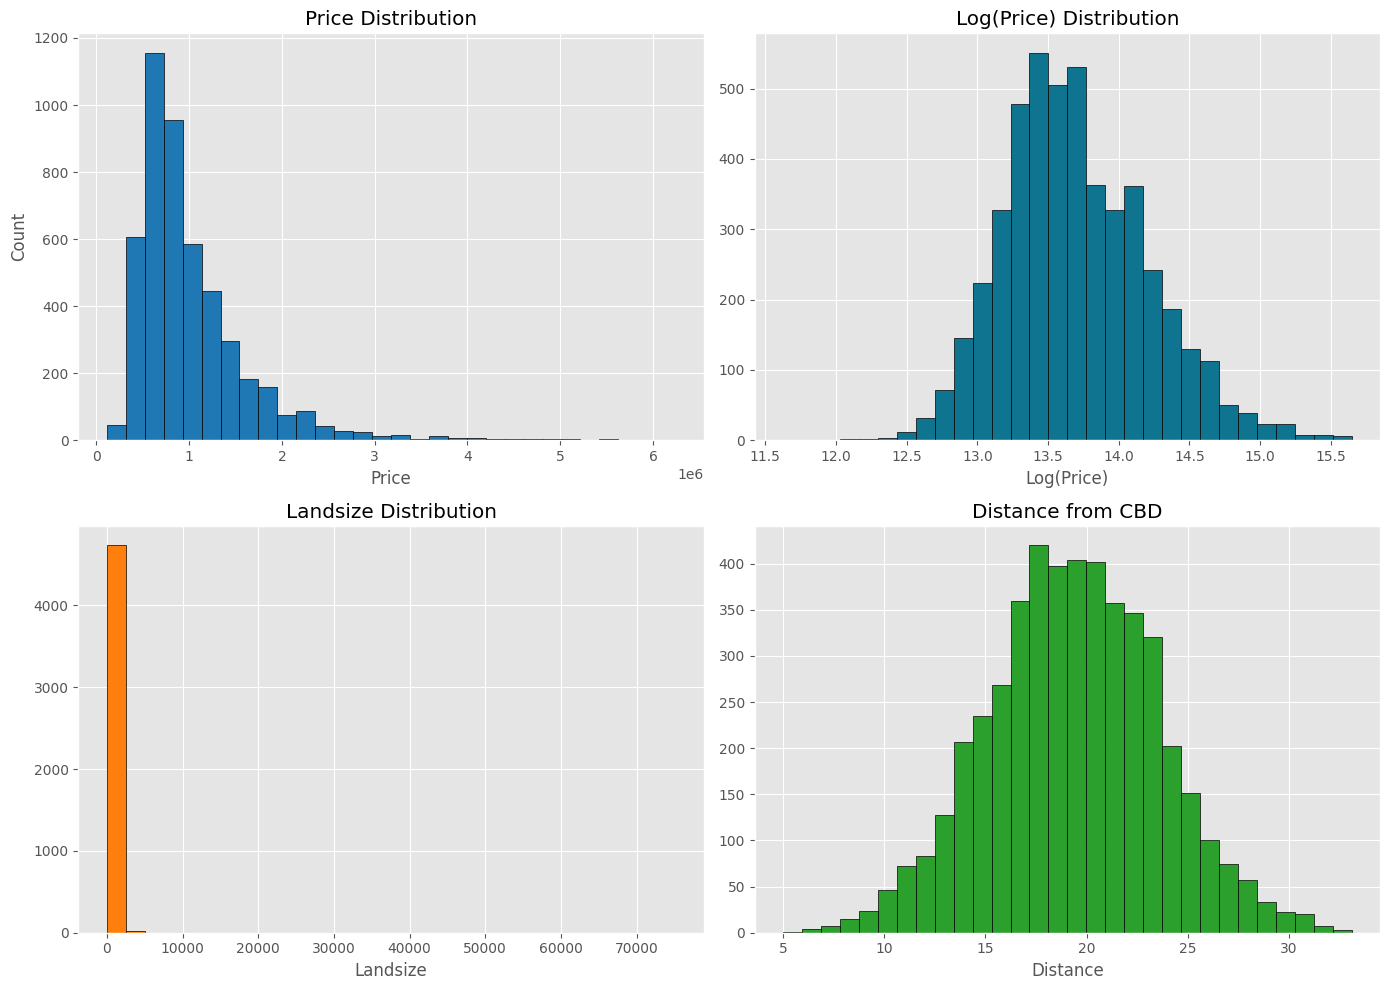

In [20]:
numeric_summary_rows = []
for column in numeric_cols:
    stats = describe_numeric([row[column] for row in records])
    numeric_summary_rows.append(
        {
            "Variable": column,
            "Min": stats["min"],
            "Q1": stats["q1"],
            "Median": stats["median"],
            "Mean": stats["mean"],
            "Q3": stats["q3"],
            "Max": stats["max"],
            "Std": stats["std"],
        }
    )
print_df("Numeric summary", numeric_summary_rows)

price_values = np.array([row["Price"] for row in records], dtype=float)
log_price_values = np.log1p(price_values)

skew_rows = [
    {"Measure": "Price", "Skewness": round(skewness(price_values), 3)},
    {"Measure": "Log(Price)", "Skewness": round(skewness(log_price_values), 3)},
]
print_df("Target skewness check", skew_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(price_values, bins=30, color="#1f77b4", edgecolor="black")
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(log_price_values, bins=30, color="#0e7490", edgecolor="black")
axes[0, 1].set_title("Log(Price) Distribution")
axes[0, 1].set_xlabel("Log(Price)")

axes[1, 0].hist([row["Landsize"] for row in records], bins=30, color="#ff7f0e", edgecolor="black")
axes[1, 0].set_title("Landsize Distribution")
axes[1, 0].set_xlabel("Landsize")

axes[1, 1].hist([row["Distance"] for row in records], bins=30, color="#2ca02c", edgecolor="black")
axes[1, 1].set_title("Distance from CBD")
axes[1, 1].set_xlabel("Distance")

plt.tight_layout()
plt.show()



## Numeric Profile Insight

The target variable is clearly **right-skewed**:

- Median `Price`: **840,000**
- Mean `Price`: **1,019,577**
- Maximum `Price`: **6,240,000**
- Raw `Price` skewness: **2.51**
- `Log(Price)` skewness: **0.45**

This shows why a log-transformed target is useful for modelling. The `Landsize` feature is also highly uneven and contains extreme values, so robust preprocessing is necessary before training models.



Property type distribution
Category Count    Pct
       h 3,353 70.350
       u   920 19.300
       t   493 10.340

Sales method distribution
Category Count    Pct
       S 3,088 64.790
      SP   662 13.890
      PI   534 11.200
      VB   446  9.360
      SA    36  0.760

Region distribution
                  Category Count    Pct
     Southern Metropolitan 1,313 27.550
     Northern Metropolitan 1,310 27.490
      Western Metropolitan   948 19.890
      Eastern Metropolitan   724 15.190
South-Eastern Metropolitan   373  7.830
         Northern Victoria    41  0.860
          Eastern Victoria    41  0.860
          Western Victoria    16  0.340



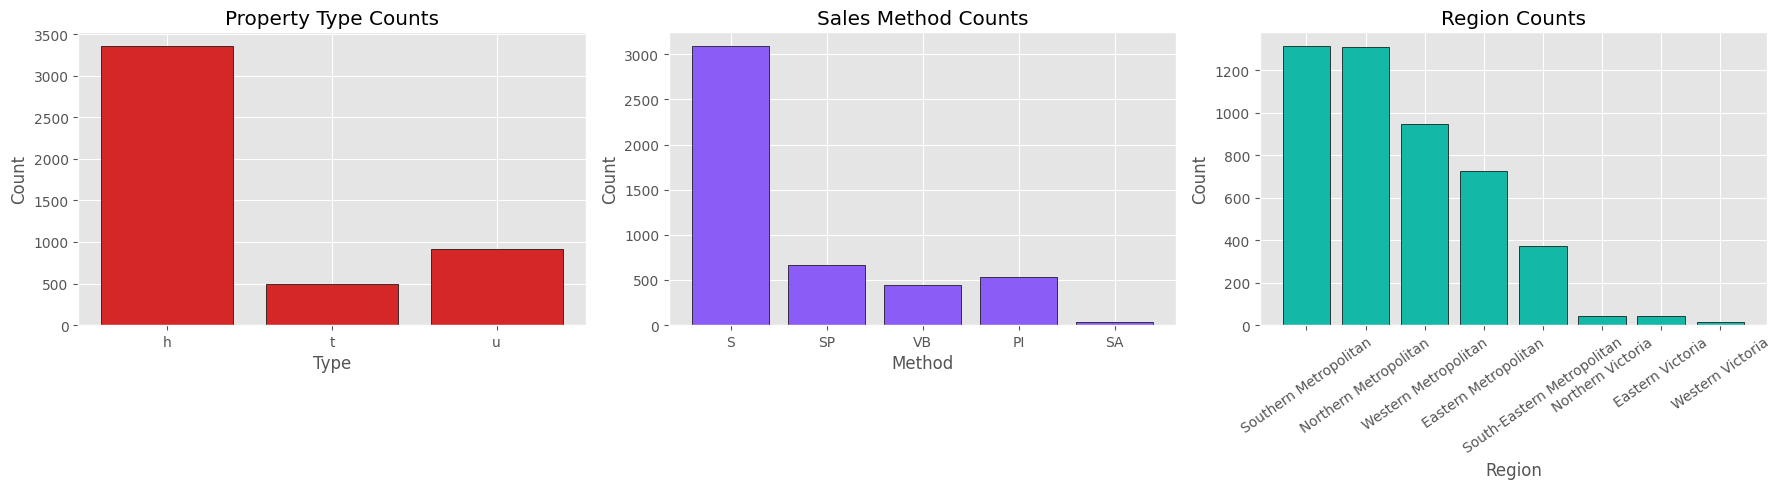

In [21]:
print_df("Property type distribution", category_summary(records, "Type"))
print_df("Sales method distribution", category_summary(records, "Method"))
print_df("Region distribution", category_summary(records, "Regionname"))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

type_counts = Counter(row["Type"] for row in records)
axes[0].bar(type_counts.keys(), type_counts.values(), color="#d62728", edgecolor="black")
axes[0].set_title("Property Type Counts")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")

method_counts = Counter(row["Method"] for row in records)
axes[1].bar(method_counts.keys(), method_counts.values(), color="#8b5cf6", edgecolor="black")
axes[1].set_title("Sales Method Counts")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Count")

region_counts = Counter(row["Regionname"] for row in records)
ordered_regions = [name for name, _ in region_counts.most_common()]
axes[2].bar(
    ordered_regions,
    [region_counts[name] for name in ordered_regions],
    color="#14b8a6",
    edgecolor="black",
)
axes[2].set_title("Region Counts")
axes[2].set_xlabel("Region")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()



## Categorical Mix Insight

The dataset is dominated by **houses (`h`)**, which account for **70.35%** of all observations. Units (`u`) make up **19.30%**, while townhouses (`t`) contribute **10.34%**.

Region coverage is concentrated in:

- `Southern Metropolitan` (**27.55%**)
- `Northern Metropolitan` (**27.49%**)
- `Western Metropolitan` (**19.89%**)

This means the dataset is richer for metropolitan suburbs than for outer Victorian regions, so models may learn Melbourne metro pricing patterns more strongly than regional ones.



Median and mean price by property type
Type Count MedianPrice     MeanPrice
   h 3,353     940,000 1,134,055.803
   t   493     840,000   909,539.083
   u   920     606,750   661,317.758

Median and mean price by selling method
Method Count MedianPrice     MeanPrice
    VB   446     940,000 1,197,724.215
    PI   534     927,500 1,096,259.176
     S 3,088     841,500 1,013,935.838
    SA    36     839,000   968,972.222
    SP   662     750,000   866,767.284

Median and mean price by region
                Regionname Count MedianPrice     MeanPrice
     Southern Metropolitan 1,313   1,250,000 1,408,083.120
      Eastern Metropolitan   724     980,000 1,074,996.175
South-Eastern Metropolitan   373     761,000   805,008.649
     Northern Metropolitan 1,310     730,000   848,609.153
      Western Metropolitan   948     696,000   803,398.234
          Eastern Victoria    41     660,100   671,831.707
         Northern Victoria    41     588,000   599,426.829
          Western Victoria    16 

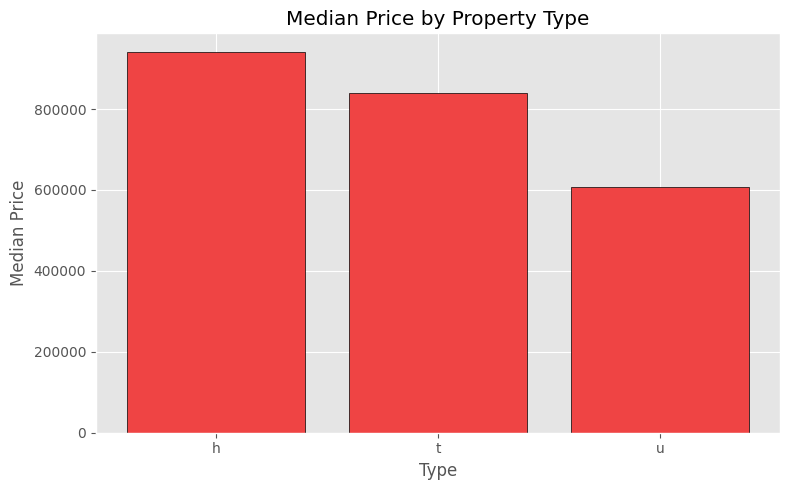

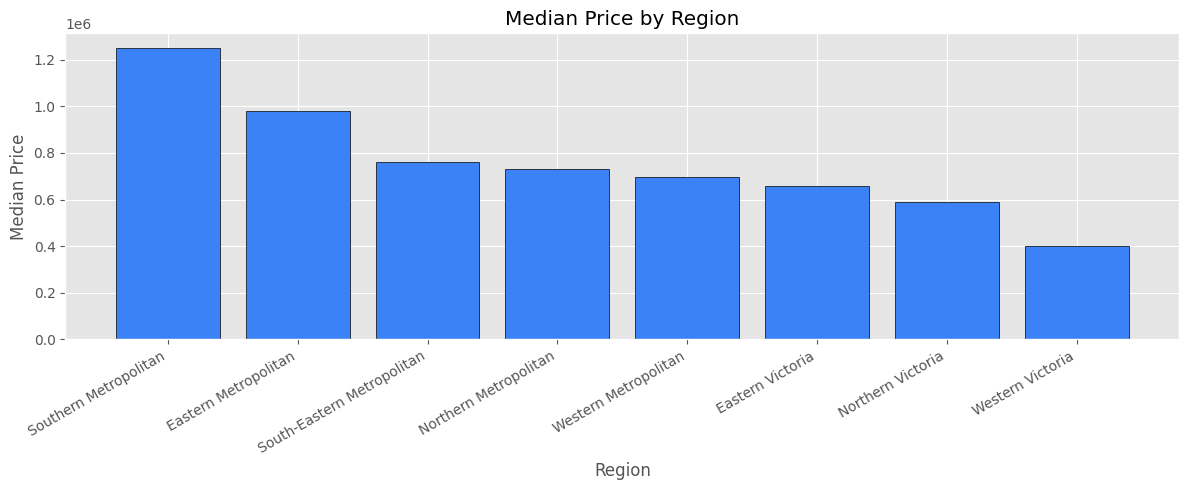

Top region-type combinations by median price (minimum 30 records)
                    Region Type Count MedianPrice     MeanPrice
     Southern Metropolitan    h   712   1,652,500 1,875,116.924
     Southern Metropolitan    t   161   1,185,000 1,231,852.720
      Eastern Metropolitan    h   553   1,065,000 1,156,497.763
      Eastern Metropolitan    t    77     910,000   946,610.130
     Northern Metropolitan    h   949     800,000   926,126.966
South-Eastern Metropolitan    h   287     800,000   854,336.153
South-Eastern Metropolitan    t    33     750,000   772,257.576
      Western Metropolitan    h   755     735,000   854,884.140
      Western Metropolitan    t    81     667,500   683,506.173
      Eastern Metropolitan    u    94     660,500   700,691.362
          Eastern Victoria    h    41     660,100   671,831.707
     Southern Metropolitan    u   440     660,000   716,821.816



In [22]:
print_df("Median and mean price by property type", print_group_price_summary(records, "Type"))
print_df("Median and mean price by selling method", print_group_price_summary(records, "Method"))
print_df("Median and mean price by region", print_group_price_summary(records, "Regionname"))

type_group = defaultdict(list)
region_group = defaultdict(list)
combo_group = defaultdict(list)

for row in records:
    type_group[row["Type"]].append(row["Price"])
    region_group[row["Regionname"]].append(row["Price"])
    combo_group[(row["Regionname"], row["Type"])].append(row["Price"])

plt.figure(figsize=(8, 5))
ordered_types = sorted(type_group, key=lambda key: np.median(type_group[key]), reverse=True)
plt.bar(
    ordered_types,
    [float(np.median(type_group[key])) for key in ordered_types],
    color="#ef4444",
    edgecolor="black",
)
plt.title("Median Price by Property Type")
plt.xlabel("Type")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
ordered_regions = sorted(region_group, key=lambda key: np.median(region_group[key]), reverse=True)
plt.bar(
    ordered_regions,
    [float(np.median(region_group[key])) for key in ordered_regions],
    color="#3b82f6",
    edgecolor="black",
)
plt.title("Median Price by Region")
plt.xlabel("Region")
plt.ylabel("Median Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

combo_rows = []
combo_ranked = sorted(
    (
        {
            "Region": region,
            "Type": property_type,
            "Count": len(values),
            "MedianPrice": float(np.median(values)),
            "MeanPrice": float(np.mean(values)),
        }
        for (region, property_type), values in combo_group.items()
        if len(values) >= 30
    ),
    key=lambda item: item["MedianPrice"],
    reverse=True,
)
combo_rows.extend(combo_ranked[:12])
print_df("Top region-type combinations by median price (minimum 30 records)", combo_rows)



## Price Segment Insight

Grouped price analysis shows strong location and property-type effects:

- Houses (`h`) have the highest median price at **940,000**
- Townhouses (`t`) follow with **840,000**
- Units (`u`) have the lowest median price at **606,750**
- `Southern Metropolitan` is the most expensive region with a median price of **1,250,000**
- The highest-priced large subgroup is **houses in Southern Metropolitan**, with a median price of **1,652,500**

These patterns suggest that **region** and **type** should be treated as high-value predictors in any price model.



Correlation with Price
Variable Correlation
   Rooms       0.403
Bathroom      -0.015
     Car      -0.012
Landsize      -0.014
Distance      -0.007
 Bedroom      -0.025

Correlation with Log(Price)
Variable Correlation
   Rooms       0.449
Bathroom      -0.017
     Car      -0.004
Landsize      -0.013
Distance      -0.009
 Bedroom      -0.027



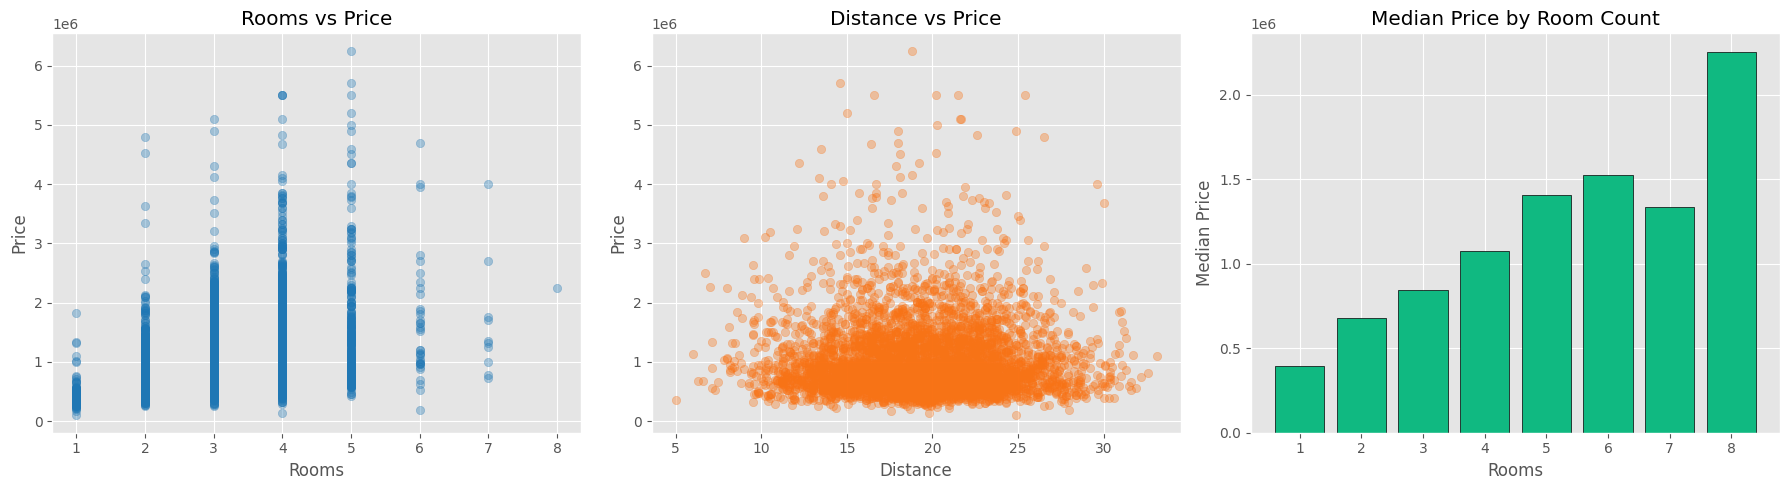

In [23]:
price_values = np.array([row["Price"] for row in records], dtype=float)
log_price_values = np.log1p(price_values)

corr_price_rows = []
for column in ["Rooms", "Bathroom", "Car", "Landsize", "Distance", "Bedroom"]:
    values = np.array([row[column] for row in records], dtype=float)
    correlation = np.corrcoef(price_values, values)[0, 1]
    corr_price_rows.append({"Variable": column, "Correlation": round(float(correlation), 3)})

corr_log_rows = []
for column in ["Rooms", "Bathroom", "Car", "Landsize", "Distance", "Bedroom"]:
    values = np.array([row[column] for row in records], dtype=float)
    correlation = np.corrcoef(log_price_values, values)[0, 1]
    corr_log_rows.append({"Variable": column, "Correlation": round(float(correlation), 3)})

print_df("Correlation with Price", corr_price_rows)
print_df("Correlation with Log(Price)", corr_log_rows)

grouped_by_rooms = defaultdict(list)
for row in records:
    grouped_by_rooms[row["Rooms"]].append(row["Price"])

ordered_rooms = sorted(grouped_by_rooms)
room_medians = [float(np.median(grouped_by_rooms[rooms])) for rooms in ordered_rooms]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    [row["Rooms"] for row in records],
    price_values,
    alpha=0.35,
    color="#1f77b4",
)
axes[0].set_title("Rooms vs Price")
axes[0].set_xlabel("Rooms")
axes[0].set_ylabel("Price")

axes[1].scatter(
    [row["Distance"] for row in records],
    price_values,
    alpha=0.35,
    color="#f97316",
)
axes[1].set_title("Distance vs Price")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Price")

axes[2].bar(ordered_rooms, room_medians, color="#10b981", edgecolor="black")
axes[2].set_title("Median Price by Room Count")
axes[2].set_xlabel("Rooms")
axes[2].set_ylabel("Median Price")

plt.tight_layout()
plt.show()



## Relationship Insight

`Rooms` is the strongest numeric signal in this dataset:

- Correlation with raw `Price`: **0.403**
- Correlation with `Log(Price)`: **0.449**

Median price rises consistently as room count increases, which makes `Rooms` a useful size-related predictor. On the other hand, single-variable linear relationships for `Bathroom`, `Car`, `Landsize`, `Distance`, and `Bedroom` are weak on their own, which suggests price is likely influenced by **feature combinations** rather than any one variable in isolation.



IQR outlier summary
Variable      Q1        Q3 LowerBound UpperBound OutlierCount OutlierPct
   Price 620,000 1,244,250   -316,375  2,180,625          253      5.310
Landsize     155       640   -572.500  1,367.500           91      1.910
Distance  16.500    22.200      7.950     30.750           31      0.650
     Car       1         2     -0.500      3.500          206      4.320
Bathroom       1         2     -0.500      3.500           71      1.490
 Bedroom       2         4         -1          7            6      0.130



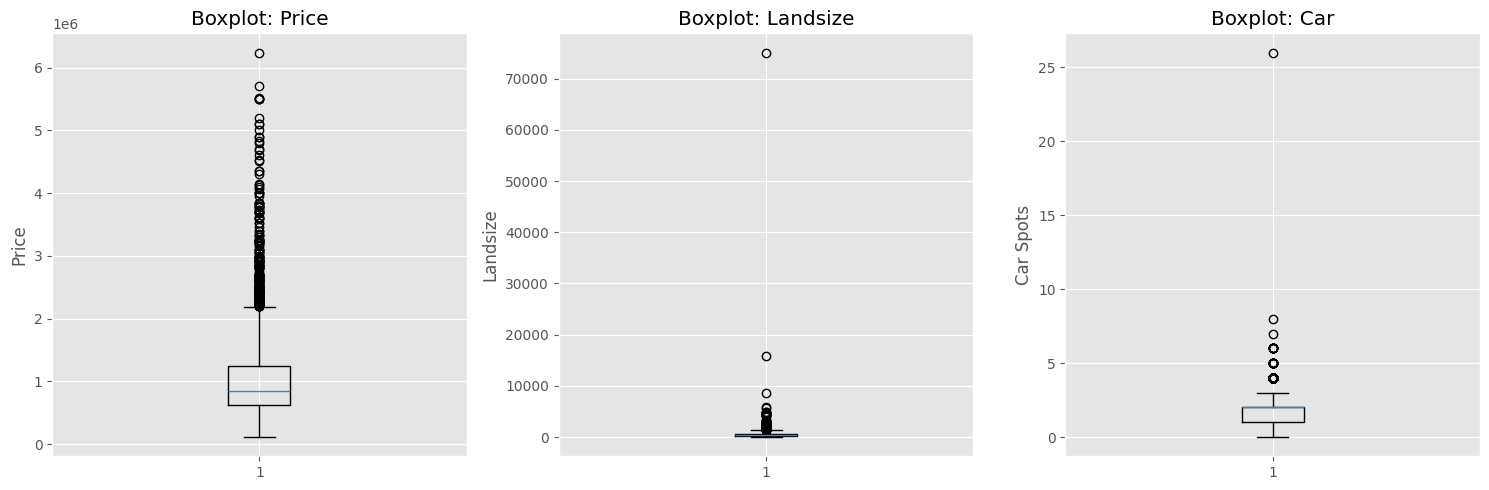

In [24]:
outlier_rows = []
for column in ["Price", "Landsize", "Distance", "Car", "Bathroom", "Bedroom"]:
    summary = iqr_outlier_summary([row[column] for row in records])
    outlier_rows.append(
        {
            "Variable": column,
            "Q1": summary["q1"],
            "Q3": summary["q3"],
            "LowerBound": summary["lower"],
            "UpperBound": summary["upper"],
            "OutlierCount": summary["count"],
            "OutlierPct": summary["pct"],
        }
    )
print_df("IQR outlier summary", outlier_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot([row["Price"] for row in records], vert=True)
axes[0].set_title("Boxplot: Price")
axes[0].set_ylabel("Price")

axes[1].boxplot([row["Landsize"] for row in records], vert=True)
axes[1].set_title("Boxplot: Landsize")
axes[1].set_ylabel("Landsize")

axes[2].boxplot([row["Car"] for row in records], vert=True)
axes[2].set_title("Boxplot: Car")
axes[2].set_ylabel("Car Spots")

plt.tight_layout()
plt.show()



## Outlier Insight

Outliers are present, but they are concentrated in a few columns:

- `Price`: **253 IQR outliers (5.31%)**
- `Landsize`: **91 IQR outliers (1.91%)**
- `Car`: **206 IQR outliers (4.32%)**

The extreme `Landsize` and `Price` values can distort model training if they are used without treatment. This is why the preparation stage uses **percentile clipping** and **robust scaling** rather than standard scaling.



In [25]:
cleaned_records = []
for row in records:
    updated = row.copy()
    updated["Bathroom_was_zero"] = int(updated["Bathroom"] == 0)
    updated["Bedroom_was_zero"] = int(updated["Bedroom"] == 0)
    updated["Landsize_was_zero"] = int(updated["Landsize"] == 0)

    if updated["Bathroom"] == 0:
        updated["Bathroom"] = None
    if updated["Bedroom"] == 0:
        updated["Bedroom"] = None
    if updated["Landsize"] == 0:
        updated["Landsize"] = None

    cleaned_records.append(updated)

feature_numeric_cols = [
    "Rooms",
    "Bathroom",
    "Car",
    "Landsize",
    "Distance",
    "Bedroom",
    "Bathroom_was_zero",
    "Bedroom_was_zero",
    "Landsize_was_zero",
]

medians = {}
clip_bounds = {}

for column in feature_numeric_cols:
    non_missing = np.array(
        [row[column] for row in cleaned_records if row[column] is not None],
        dtype=float,
    )
    medians[column] = float(np.median(non_missing))
    clip_bounds[column] = tuple(np.percentile(non_missing, [1, 99]))

prep_rows = []
for column in feature_numeric_cols:
    prep_rows.append(
        {
            "Feature": column,
            "MedianUsed": medians[column],
            "ClipLower": clip_bounds[column][0],
            "ClipUpper": clip_bounds[column][1],
        }
    )
print_df("Median imputation and clipping values", prep_rows)



Median imputation and clipping values
          Feature MedianUsed ClipLower ClipUpper
            Rooms          3         1         5
         Bathroom          1         1         4
              Car          2         0         4
         Landsize        495        76 2,127.320
         Distance     19.300     9.600    29.535
          Bedroom          3         1         5
Bathroom_was_zero          0         0         0
 Bedroom_was_zero          0         0         0
Landsize_was_zero          0         0         1



## Preparation Insight

The preparation logic is deliberately conservative:

- Suspicious zeros in `Bathroom`, `Bedroom`, and `Landsize` are converted into missing-like values
- Binary indicator features preserve the information that these zeros originally occurred
- Numeric fields are clipped at the **1st and 99th percentiles**
- `RobustScaler` is used to reduce the influence of skew and outliers

This makes the final dataset better suited for both linear and tree-based predictive models.



In [26]:
model_records = []
for row in cleaned_records:
    model_row = {}
    for column in feature_numeric_cols:
        value = medians[column] if row[column] is None else float(row[column])
        lower, upper = clip_bounds[column]
        model_row[column] = float(np.clip(value, lower, upper))
    for column in categorical_cols:
        model_row[column] = row[column]
    model_records.append(model_row)

numeric_matrix = np.array(
    [[row[column] for column in feature_numeric_cols] for row in model_records],
    dtype=float,
)

scaler = RobustScaler()
numeric_scaled = scaler.fit_transform(numeric_matrix)

categorical_records = [
    {column: row[column] for column in categorical_cols}
    for row in model_records
]

vectorizer = DictVectorizer(sparse=False)
categorical_matrix = vectorizer.fit_transform(categorical_records)

X_prepared = np.hstack([numeric_scaled, categorical_matrix])
y = np.array([row["Price"] for row in records], dtype=float)
y_log = np.log1p(y)

feature_names = feature_numeric_cols + vectorizer.get_feature_names_out().tolist()

matrix_rows = [
    {"Metric": "Prepared feature rows", "Value": X_prepared.shape[0]},
    {"Metric": "Prepared feature columns", "Value": X_prepared.shape[1]},
    {"Metric": "Number of feature names", "Value": len(feature_names)},
]
print_df("Prepared feature matrix summary", matrix_rows)

feature_preview_rows = [{"FeatureName": name} for name in feature_names[:12]]
print_df("First 12 feature names", feature_preview_rows)



Prepared feature matrix summary
                  Metric Value
   Prepared feature rows 4,766
Prepared feature columns    25
 Number of feature names    25

First 12 feature names
      FeatureName
            Rooms
         Bathroom
              Car
         Landsize
         Distance
          Bedroom
Bathroom_was_zero
 Bedroom_was_zero
Landsize_was_zero
        Method=PI
         Method=S
        Method=SA



## Feature Matrix Insight

After encoding and scaling, the final modelling matrix contains **22 input features**. It combines:

- Cleaned and scaled numeric features
- Missing-value indicator flags
- One-hot encoded categorical variables for `Type`, `Method`, and `Regionname`

This is a strong baseline feature set for predictive modelling, especially because it preserves both the main measurements and important data-quality signals.



In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    y,
    test_size=0.2,
    random_state=42,
)

split_rows = [
    {"Split": "Train", "Rows": X_train.shape[0], "Columns": X_train.shape[1]},
    {"Split": "Test", "Rows": X_test.shape[0], "Columns": X_test.shape[1]},
]
print_df("Train-test split summary", split_rows)

prepared_df = pd.DataFrame(X_prepared, columns=feature_names)
prepared_df["Price"] = y
prepared_df["LogPrice"] = y_log
prepared_df.to_csv(PREPARED_PATH, index=False)

export_rows = [
    {"OutputFile": PREPARED_PATH.name, "RowsWritten": len(X_prepared), "TargetColumns": 2},
]
print_df("Prepared dataset export", export_rows)



Train-test split summary
Split  Rows Columns
Train 3,812      25
 Test   954      25

Prepared dataset export
                         OutputFile RowsWritten TargetColumns
melbourne_prepared_for_modeling.csv       4,766             2



## Final Conclusion

This dataset is now ready for predictive modelling. The strongest takeaways from the EDA are:

- `Price` is right-skewed, so **`LogPrice` is a good modelling target**
- **Region** and **property type** are strong pricing signals
- **Room count** is the most useful single numeric predictor
- The dataset contains several suspicious zero values and a small number of strong outliers, all of which have been handled in the preparation flow

### Recommended next models

- Linear Regression on `LogPrice`
- Random Forest Regressor
- Gradient Boosting Regressor

